# Project Milestone One: Form Your Team, Understand the Problem, and Explore the Data

#### **Due:** July 12th @ 11:59 PM (with a 2 hour & 1 minute grace period)

#### **Important:** There is **no late period** for this assignment, as manual grading must begin immediately after the deadline.

## What You Will Do in This Milestone

1. Form your project team and complete the **Team Contract** (available in the Homework Repository). Submit one copy to Gradescope.
2. Select a **team leader**, who will submit this notebook on behalf of the team after everyone has contributed to the assignment. This <a href=https://guides.gradescope.com/hc/en-us/articles/21863861823373-Adding-Group-Members-to-a-Submission>Gradescope guide</a> explains how to add group members to a submission.
3. After completing this milestone, **each team member** must complete an **Individual Team Evaluation** (available in the Homework Repository) and submit it individually to Gradescope.
4. Complete a simplified version of the **Machine Learning Project Checklist** from Appendix A of *Hands-On Machine Learning* (p. 779):

> **Part 1:** Frame the problem and understand the project goals   
> **Part 2:** Explore and understand the dataset   
> **Part 3:** Clean and prepare the data   
> **Part 4:** Investigate feature relationships   
> **Part 5:** Develop hypotheses for feature engineering and preprocessing

## The Dataset

All teams will work with the same dataset: a reduced version of the Zillow housing dataset used in the **Zillow Prize** competition on Kaggle in 2017 (unfortunately, the competition has long since ended!).

Your goal is to predict a property's **assessed tax value** (`taxvaluedollarcnt`) from a large collection of property characteristics. The dataset contains many of the challenges encountered in real machine learning projects, including:

* Missing values
* Potential outliers
* Redundant and highly correlated features
* Identifier variables that may not be useful for prediction
* Features that require careful interpretation before preprocessing

Unlike many educational datasets, this one has **not** been extensively preprocessed. Throughout this milestone, your objective is to understand the data, identify potential issues, and develop hypotheses about preprocessing and feature engineering. In **Milestone 2**, you will evaluate many of these ideas experimentally to determine whether they actually improve model performance.



In [154]:
# =============================
# Useful Imports
# =============================

# Standard Libraries
import os
import time
import math
import io
import zipfile
import requests
from urllib.parse import urlparse
from itertools import chain, combinations

# Data Science Libraries
import numpy as np
import pandas as pd
import seaborn as sns

# Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.ticker as mticker  # Optional: Format y-axis labels as dollars

# Scikit-learn (Machine Learning)
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV,
    RandomizedSearchCV,
    RepeatedKFold
)
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error
from sklearn.feature_selection import SequentialFeatureSelector, f_regression, SelectKBest
from sklearn.datasets import make_regression
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor, GradientBoostingRegressor

# Kaggle and Progress Tracking
from tqdm import tqdm

# =============================
# Global Variables
# =============================
random_state = 42

# =============================
# Utility Functions
# =============================

# Format y-axis labels as dollars with commas (optional)
def dollar_format(x, pos):
    return f'${x:,.0f}'

# Convert seconds to HH:MM:SS format
def format_hms(seconds):
    return time.strftime("%H:%M:%S", time.gmtime(seconds))



## Prelude: Download the Zillow Housing Dataset

The code cell below will load the dataset for you.    

> **Notice that before downloading, this cell first checks whether the files already exist.**

For a detailed description of the dataset features, please refer to  **Appendix 1** below.


In [155]:

url = "https://www.cs.bu.edu/fac/snyder/cs505/Data/zillow_dataset.csv"

filename = os.path.basename(urlparse(url).path)

if not os.path.exists(filename):
    try:
        print("Downloading the file...")
        response = requests.get(url)
        response.raise_for_status()  # Raise an error for bad status codes
        with open(filename, "wb") as f:
            f.write(response.content)
        print("File downloaded successfully.")
    except requests.exceptions.RequestException as e:
        print(f"Error downloading the file: {e}")
else:
    print("File already exists. Skipping download.")

df = pd.read_csv(filename)

File already exists. Skipping download.


## Part 1: Frame the problem and look at the big picture [3 pts]

This part is a bit vague, since this project is not taking place in an actual business, but for the sake of exercising all the steps, **pretend** that you are working at Zillow as a data analyst and are given this dataset and asked to
- Analyze and understand the data;
- Develop a regression model;
- Give a presentation to the marketing team about your results.  

#### **1 Discussion:**

AFTER doing your EDA, come back and answer each of the following 3 questions in a *concise and informative paragraph between the lines;* you may wish to use your own business or home-buying experience, or to do some online research about the issues before you propose your ideas. (Don't stress about this, but *humor your professor and give it your best shot!*)


**1.1:**  What is the objective of this project in business terms?

> The objective of this project is to predict the tax value of the properties based on their charisteristics such as size, number of rooms, location etc. This objective is helpful for companies like Zillow and buyers to know the hidden cost of taxes so as to improve the home searching/buying experience.


**1.2:**  How will your solution be used?

> This solution will be done in the back end of the real estate platform in real time whenever a listing is uploaded or updated. This solution will return the estimated taxes along with other costs not only for the realtors but also the customers among with other estimates


**1.3:**  How should success (or failure) be measured?

> If the models predicted tax estimate is within a relatively small range of the actual, controlled tax burden on verified homes as described by the taxvaluedollarcnt feature.

## Part 2: Download and perform preliminary exploration of the data [4 pts]

### Part 2.A: Load the data into a dataframe and study each feature/column and its characteristics:
- Feature Name
- Type (categorical, int/float, text, etc.)
- Apparent usefulness for the task
- Approximate % of missing values
- How many unique values

**Note:** The **target** is the last column `'taxvaluedollarcnt'` -- pay particular attention to this during the EDA process.
  
Hint: Just use `.head()`, `.info()`, and `.nunique()`.

In [156]:
from pandas._libs import missing
#view first 5 rows to see columns and feature names
print('FEATURE NAMES')
print(df.head())

#examine feature types
print('\nFEATURE TYPE')
print(df.info())

#count unique values
print('\nUNIQUE VALUES')
print(df.nunique())

#calculate % of missing values per column
print('\nPERCENTAGE OF MISSING VALUES')
missing_pctg = (df.isnull().sum()/ len(df))*100
print(missing_pctg.sort_values(ascending = False))


FEATURE NAMES
   parcelid  airconditioningtypeid  architecturalstyletypeid  basementsqft  \
0  14297519                    NaN                       NaN           NaN   
1  17052889                    NaN                       NaN           NaN   
2  14186244                    NaN                       NaN           NaN   
3  12177905                    NaN                       NaN           NaN   
4  10887214                    1.0                       NaN           NaN   

   bathroomcnt  bedroomcnt  buildingclasstypeid  buildingqualitytypeid  \
0          3.5         4.0                  NaN                    NaN   
1          1.0         2.0                  NaN                    NaN   
2          2.0         3.0                  NaN                    NaN   
3          3.0         4.0                  NaN                    8.0   
4          3.0         3.0                  NaN                    8.0   

   calculatedbathnbr  decktypeid  ...  yardbuildingsqft17  yardbuildings

In [157]:
# Categorical features:

df_categorical = df.select_dtypes(include=['object', 'category'])
df_categorical.head()

,hashottuborspa,propertycountylandusecode,propertyzoningdesc,fireplaceflag,taxdelinquencyflag
0,NaN,122,NaN,NaN,NaN
1,NaN,1110,NaN,NaN,NaN
2,NaN,122,NaN,NaN,NaN
3,NaN,0101,LCR110000*,NaN,NaN
4,NaN,010C,LAR3,NaN,NaN


#### **2.A Discussion:**

Answer the following questions. You may wish to examine Appendix 3 before starting.

**2.A.1:**  Which features are categorical?

> "hashottuborspa", "propertycountylandusecode", "propertyzoningdesc", "fireplaceflag", "taxdelinquencyflag"

**2.A.2:**  Are there any features which appear at first glance to be **useless** for the business purpose of this project and should be deleted?  Give examples and describe your reasoning briefly.

> "heatingorsystemtypeid" is the only feature that I could foresee being entirely useless to calculate property tax. The type of HVAC system isn't included when calculating property taxes.

**2.A.3:**  Are there any features which appear to be **useless** because of the percentage of missing values?  If so, give an example.

> Yes, there are 22 features which have 10% or less of the rows missing data. For example yearbuilt has less than 1% of the values available within the dataset.

**2.A.4:**  Are there any features which appear to be **useless** because of the number of unique values?  If so, give an example.

> Yes, once again assessmentyear only has one unique value which isn't at all helpful. Storytypeid which I assume refers to the number of stories in the home, only has one unique ID which would indicate that it only has listings likely for a one story home, which is in now way useful for building a model.

### Part 2.B: Exploratory Data Analysis (EDA) -- Feature-Level Visualization  

- To get an overview, generate histograms for all features using `df.hist()`  (Hint: increase the figsize and set the layout to `(-1,m)` to get  `m` columns and as many rows as necessary.)
- Generate individual visualizations for the target and three (3) additional features that you believe are particularly informative or interesting (a total of four features):
    - Use appropriate plot types (e.g., histograms and boxplots for numerical features, bar plots for categorical features) to understand distributions and identify potential outliers for these three.
    - Use as many code cells as you need, and give comments describing what each cell does.
    - Answer the discussion question posed (you should choose 3 features for which you can say something interesting in the discussion).  

----------------------------
HISTOGRAM FOR ALL FEATURES
----------------------------


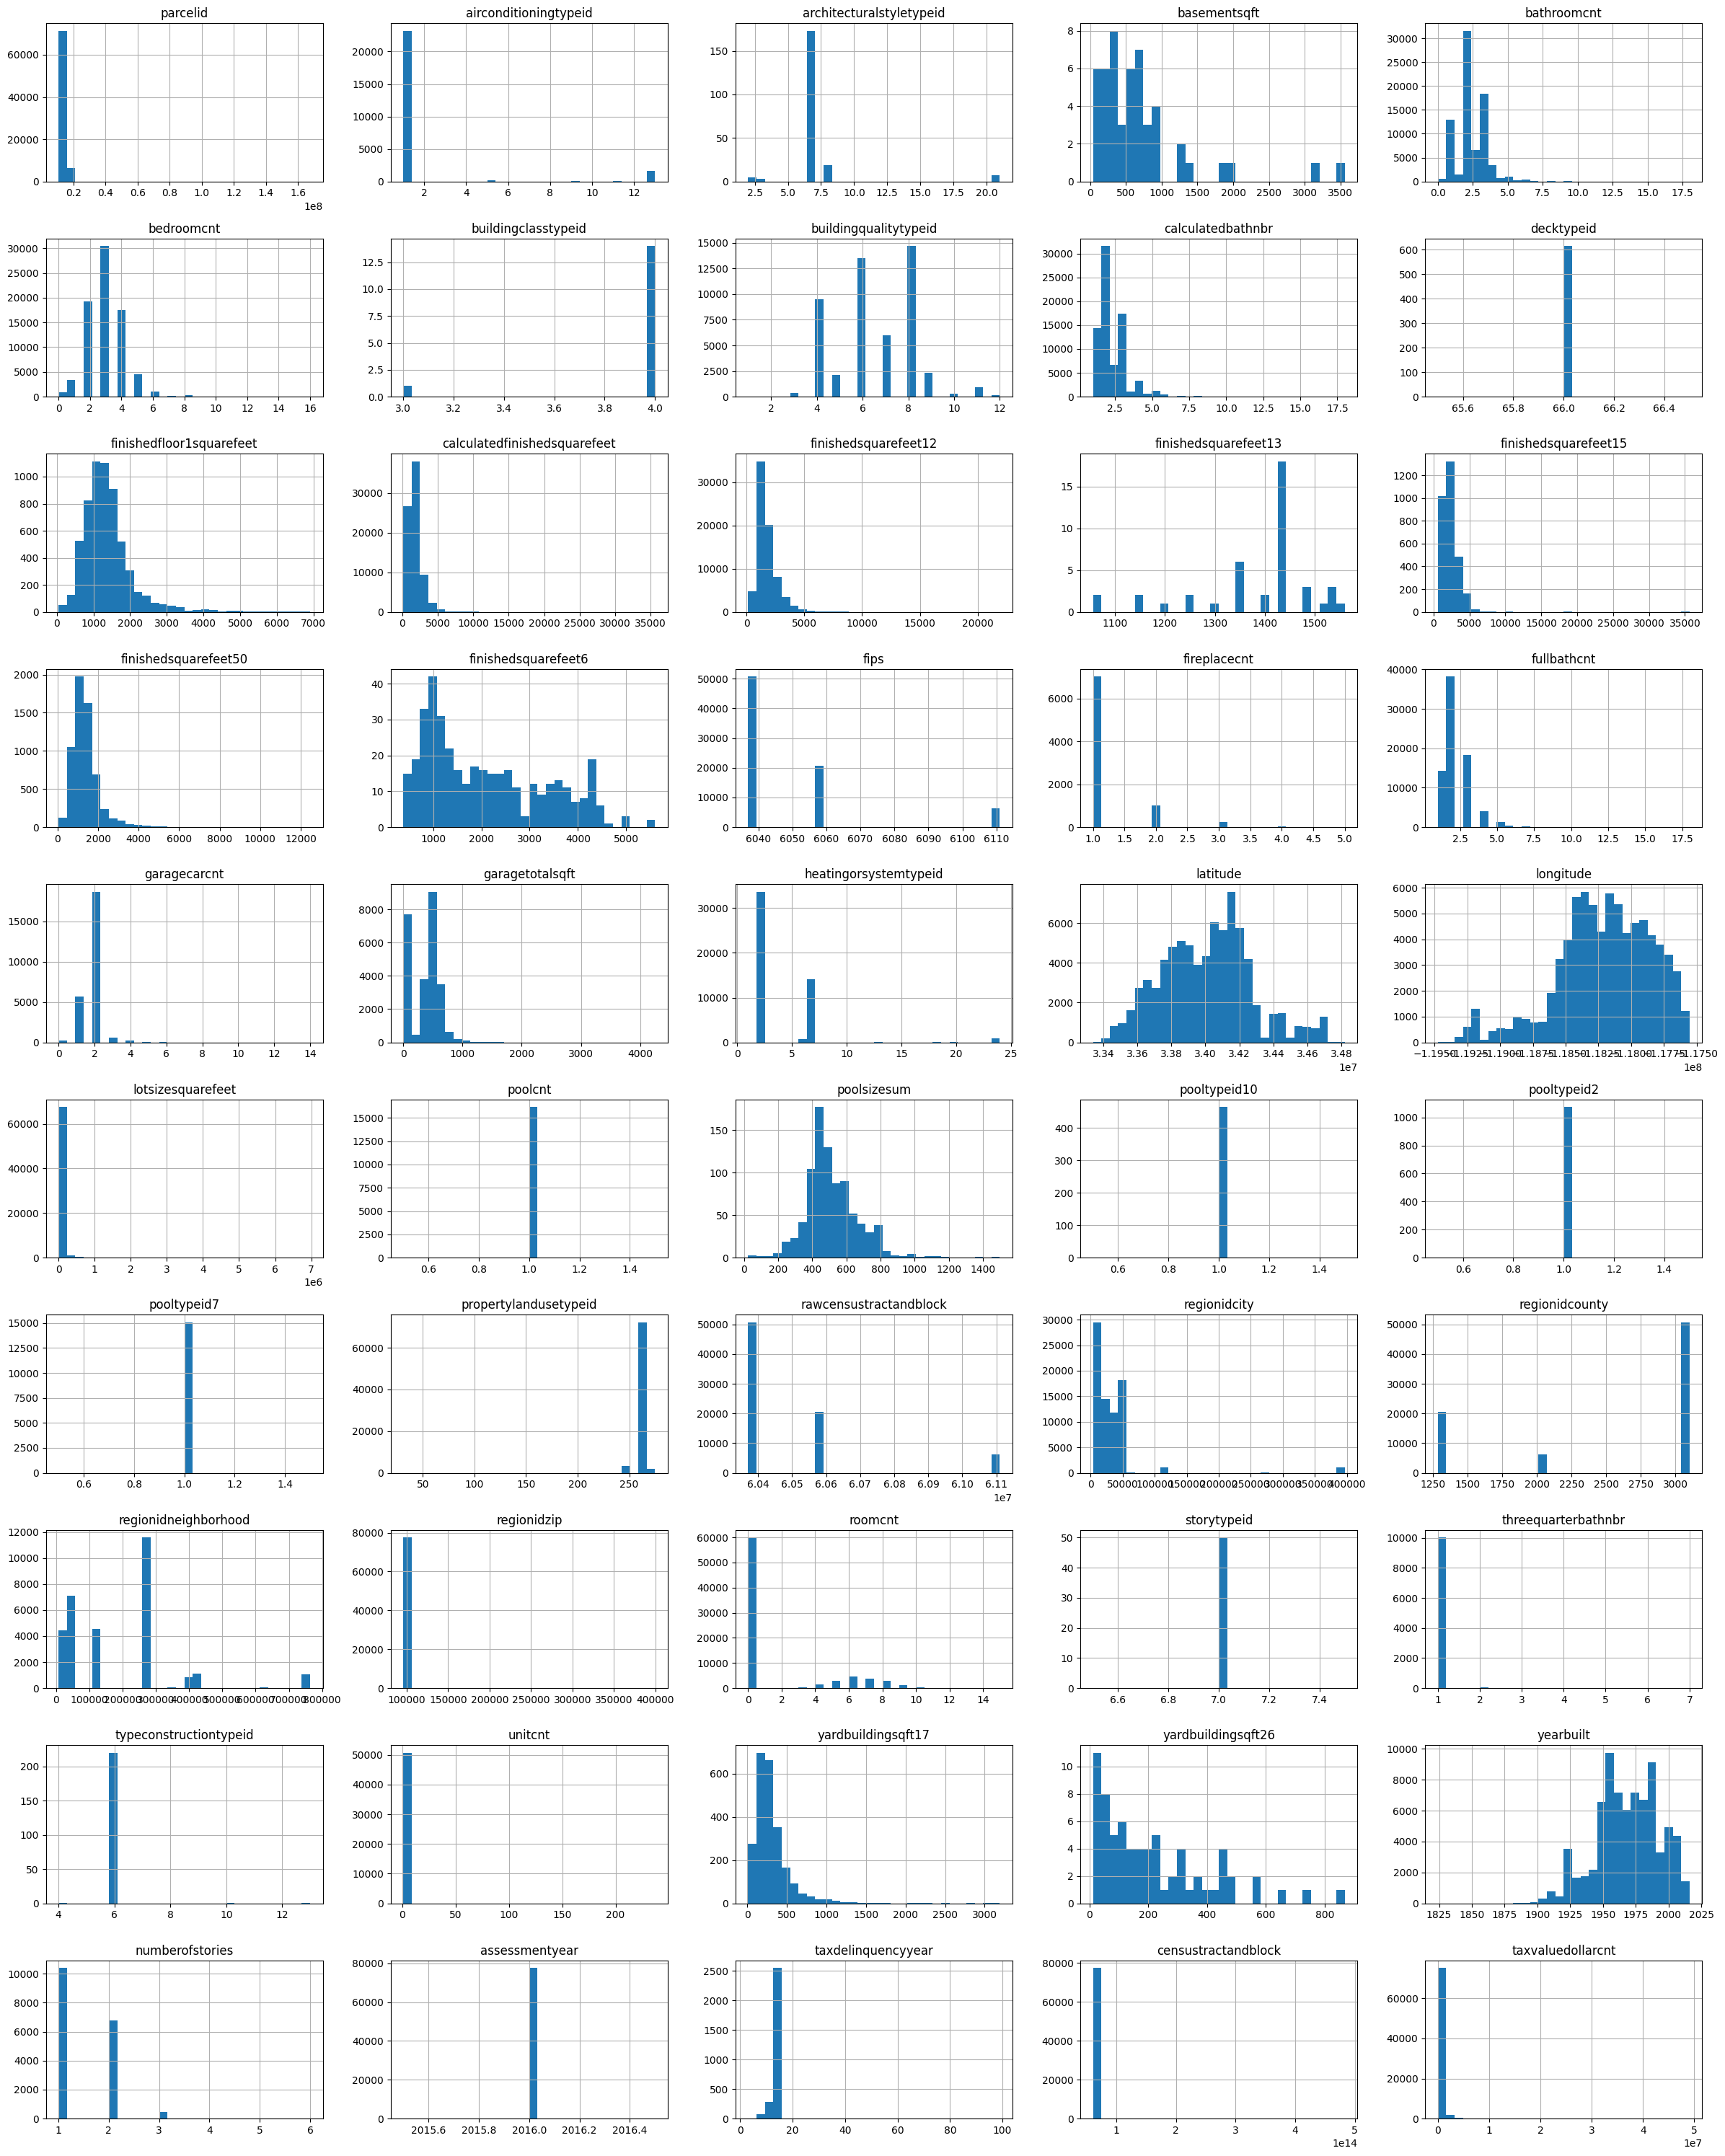

----------------------------
HISTOGRAM OF taxvaluedollercnt
----------------------------


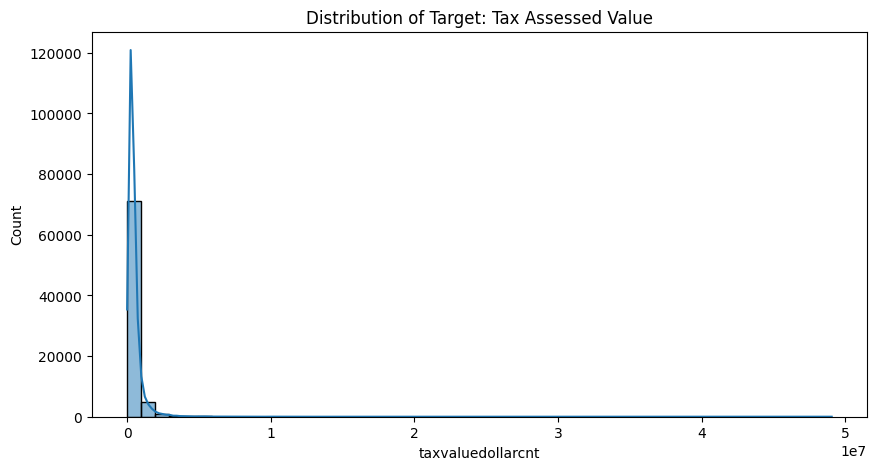

----------------------------
SCATTERPLOT OF calculatedfinishedsquarefeet
----------------------------


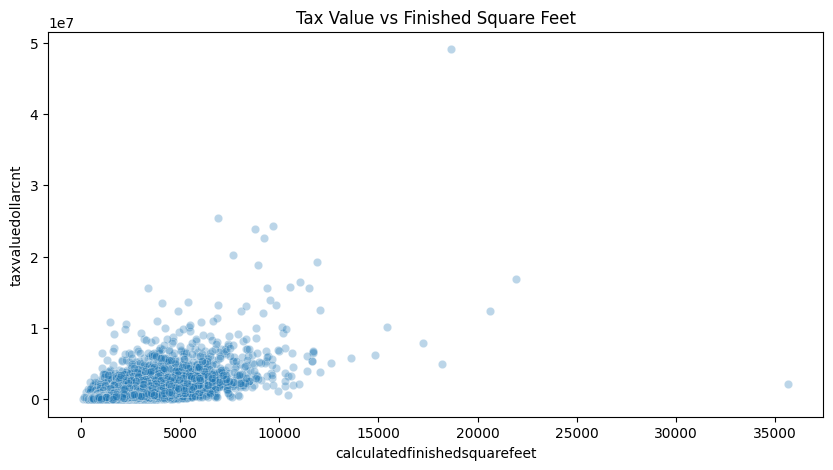

----------------------------
HISTOGRAM OF yearbuilt
----------------------------


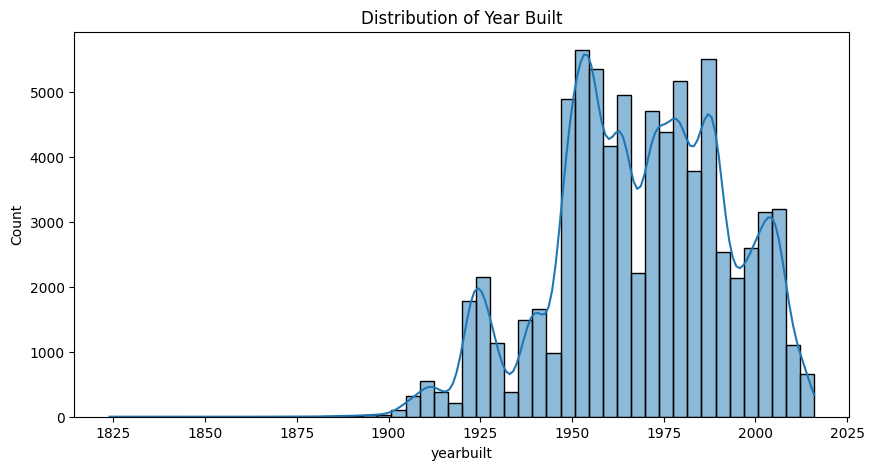

----------------------------
BOXPLOT OF bedroomcnt
----------------------------


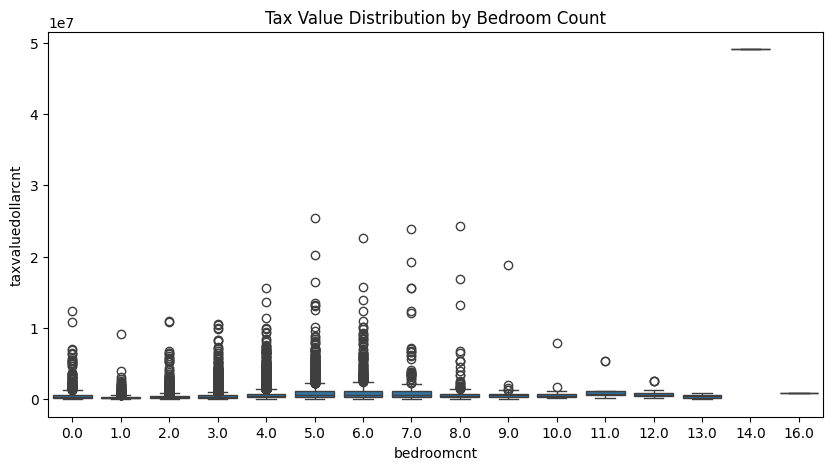

In [158]:
print('----------------------------\nHISTOGRAM FOR ALL FEATURES\n----------------------------')
df.hist(figsize=(24,30), bins=30, layout=(-1,5))
plt.tight_layout()
plt.show()

# 1. Target Variable: taxvaluedollarcnt. Plotting a histogram of this target variable
print('----------------------------\nHISTOGRAM OF taxvaluedollercnt\n----------------------------')
plt.figure(figsize=(10, 5))
sns.histplot(df['taxvaluedollarcnt'], bins=50, kde=True)
plt.title('Distribution of Target: Tax Assessed Value')
plt.show()

# 2. Feature 1: calculatedfinishedsquarefeet (Numerical)
print('----------------------------\nSCATTERPLOT OF calculatedfinishedsquarefeet\n----------------------------')
plt.figure(figsize=(10, 5))
sns.scatterplot(x=df['calculatedfinishedsquarefeet'], y=df['taxvaluedollarcnt'], alpha=0.3)
plt.title('Tax Value vs Finished Square Feet')
plt.show()

# 3. Feature 2: yearbuilt (Numerical/Time)
print('----------------------------\nHISTOGRAM OF yearbuilt\n----------------------------')
plt.figure(figsize=(10, 5))
sns.histplot(df['yearbuilt'], bins=50, kde=True)
plt.title('Distribution of Year Built')
plt.show()

# 4. Feature 3: bedroomcnt (Discrete/Ordinal)
print('----------------------------\nBOXPLOT OF bedroomcnt\n----------------------------')
plt.figure(figsize=(10, 5))
sns.boxplot(x=df['bedroomcnt'], y=df['taxvaluedollarcnt'])
plt.title('Tax Value Distribution by Bedroom Count')
plt.show()

#### **2.B Discussion:**

Describe what you learned from your detailed examination of the four features you selected. For each feature, discuss:

- The overall distribution (for example, approximately normal, skewed, or multimodal).
- Any notable characteristics, such as outliers, unusual values, or missing data.
- Why you selected the feature and what you learned about the dataset from examining it.

Conclude by briefly discussing whether any of the features you examined might require additional preprocessing later in the project (such as imputation, transformation, or outlier investigation).

> Tax Value vs Finished Square Feet has a clear linear relationship which makes sense as they are highly correlated features - this is also a reason for selecting these features to investigate. There are several outliers in this relationship, one likely from a very high value home (~17,000 sqrft) with an exceptionally high tax value, and another with an enormous Square (~35,000 sqrft) footage with an almost nonexistant tax value.



> Distribution of Target: Tax Assessed Value is a single spike one the nearly zero amount.



>Distribution of Year Built is roughly normally distributed with a slight left skew with a range from years 1900 to around 2012. There are notable increases in the number of homes built corresponding to major economic and historical events. For instance the "Roaring 20s" with an increase in homes centered around 1925, in the post war boom of the 1950s, which stayed high, with some mild fluctuations, up until the 1980's.



> Tax Value Distribution by Bedroom Count has a roughly normal distribution which is noteworthy because the most intuitive relationship between rooms and tax value is a linear one. However the tax value appears to peak around the 5 and 6 bedroom number and then taper off where 9+ bedrooms appear to have little to no tax value. There is no simple reason to offer that describes why this relationship is recorded that way.



## Part 3:  Clean the Data: Drop, Impute, and Encode [6 pts]



**Important Notes:**
- You should review your Homework 4 before doing this section!
- Create new names for modified data at each stage to avoid problems with global variables.
- Whenever possible, write functions for all data transformations you apply, for these reasons:
    - So you can easily prepare the data the next time you get a fresh dataset
    - So you can apply these transformations in future projects
    - To clean and prepare new data instances once your solution is live
    - To make it easy to treat your preparation choices as hyperparameters
    - [To apply the same transformations to your test set if train/test split already done -- not applicable here]

### Part 3.A: Drop features you judge to be unsuitable for the regression task

Your call, based on any research you can do to understand the feature (hopefully IRL you would have a domain expert to help with this, but do your best).   

Note: Do not drop features because of too many missing values, that's the next task!

In [159]:
cols_to_drop = ['parcelid','rawcensustractandblock','censustractandblock']
df_cleaned = df.drop(columns = [col for col in cols_to_drop]).copy()

#### **3.A Discussion:**

Describe the features you chose to remove, if any, and justify each decision. For each feature, explain:

- Why you believed it was unsuitable for predicting the target.
- Which characteristic led to your decision (for example, an identifier, irrelevant information, or another reason).
- Why your decision was based on the feature's meaning rather than the amount of missing data.

If you chose not to remove any features, explain why.

> Replace this text with your answer

>We removed parcelid, rawcensustractandblock, and censustractandblock because they function primarily as record or geographic identifiers rather than direct property measurements. parcelid uniquely identifies individual records and is unlikely to generalize to new properties. The census tract and block variables are highly specific geographic codes that may act like identifiers and could encourage the model to memorize locations. These features were removed because of their meaning, not because of missing values.

### Part 3.B: Drop **features** with "too many" null values

Your code in the next cell(s). Make a judgement call about what "too many" means and briefly describe your reasoning in the discussion.   

Note: "Too many" may depend on what the non-null values look like, be sure to investigate carefully.

In [160]:
# missing_pct_cleaned = df_cleaned.isna().mean() * 100

# cols_too_many_nulls = (
#     missing_pct_cleaned[missing_pct_cleaned > 50]
#     .index
#     .tolist()
# )

# print(
#     f"Dropping columns with more than 50% missing data: "
#     f"{cols_too_many_nulls}"
# )

# df_reduced = df_cleaned.drop(
#     columns=cols_too_many_nulls
# ).copy()

# df_reduced.head()

In [161]:
cols_too_many_nulls = missing_pctg[missing_pctg>50].index.tolist()
print(f'Dropping columns with more than 50% missing data:{cols_too_many_nulls}')
df_reduced = df_cleaned.drop(columns = cols_too_many_nulls).copy()
df_reduced.head()

Dropping columns with more than 50% missing data:['airconditioningtypeid', 'architecturalstyletypeid', 'basementsqft', 'buildingclasstypeid', 'decktypeid', 'finishedfloor1squarefeet', 'finishedsquarefeet13', 'finishedsquarefeet15', 'finishedsquarefeet50', 'finishedsquarefeet6', 'fireplacecnt', 'garagecarcnt', 'garagetotalsqft', 'hashottuborspa', 'poolcnt', 'poolsizesum', 'pooltypeid10', 'pooltypeid2', 'pooltypeid7', 'regionidneighborhood', 'storytypeid', 'threequarterbathnbr', 'typeconstructiontypeid', 'yardbuildingsqft17', 'yardbuildingsqft26', 'numberofstories', 'fireplaceflag', 'taxdelinquencyflag', 'taxdelinquencyyear']


,bathroomcnt,bedroomcnt,buildingqualitytypeid,calculatedbathnbr,calculatedfinishedsquarefeet,finishedsquarefeet12,fips,fullbathcnt,heatingorsystemtypeid,latitude,...,propertylandusetypeid,propertyzoningdesc,regionidcity,regionidcounty,regionidzip,roomcnt,unitcnt,yearbuilt,assessmentyear,taxvaluedollarcnt
0,3.5,4.0,NaN,3.5,3100.0,3100.0,6059.0,3.0,NaN,33634931.0,...,261.0,NaN,53571.0,1286.0,96978.0,0.0,NaN,1998.0,2016.0,1023282.0
1,1.0,2.0,NaN,1.0,1465.0,1465.0,6111.0,1.0,NaN,34449266.0,...,261.0,NaN,13091.0,2061.0,97099.0,5.0,NaN,1967.0,2016.0,464000.0
2,2.0,3.0,NaN,2.0,1243.0,1243.0,6059.0,2.0,NaN,33886168.0,...,261.0,NaN,21412.0,1286.0,97078.0,6.0,NaN,1962.0,2016.0,564778.0
3,3.0,4.0,8.0,3.0,2376.0,2376.0,6037.0,3.0,2.0,34245180.0,...,261.0,LCR110000*,396551.0,3101.0,96330.0,0.0,1.0,1970.0,2016.0,145143.0
4,3.0,3.0,8.0,3.0,1312.0,1312.0,6037.0,3.0,2.0,34185120.0,...,266.0,LAR3,12447.0,3101.0,96451.0,0.0,1.0,1964.0,2016.0,119407.0


#### **3.B Discussion:**

Describe the criteria you used to decide which features had **too many** missing values to retain.

In particular, explain:

- The threshold you selected for determining when a feature should be removed.
- Why you believe this threshold was appropriate for this dataset.
- Whether you considered the usefulness of the remaining non-null values before deciding to remove a feature, and how this influenced your decision.

> - We selected the threshold at 50%. Any column with more than 50% missing value is removed
> - If we decide to apply imputation to these columns with missing values, with methods like applying mean, median or mode, anything with over than 50% would introduce bias
> - While some removed features may seem important and might mean 0 when missing, the risk of skewing the data distribution and affect the model is high if we keep them. And we believe that the remaining features should be sufficient.

### Part 3.C: Remove Problematic Samples

Some samples may not be suitable for model training because they contain insufficient information or cannot be used for supervised learning.

- Remove any sample with a missing target value.
- Decide on a reasonable threshold for the maximum percentage of missing feature values in a sample, justify your choice, and remove samples exceeding that threshold.
- Investigate whether the dataset contains potential outliers, but **do not remove them yet.** Instead, describe how you identified them and explain why removing them may or may not be appropriate. Their effect on model performance will be investigated in Milestone 2.

Your code in the next cell(s). Make a judgement call about which samples should be dropped and briefly describe your reasoning in the discussion.   


In [162]:
df_samples = df_reduced.dropna(subset=['taxvaluedollarcnt']).copy()
row_missing_pctg = (df_samples.isnull().sum(axis=1))/df_samples.shape[1]*100
df_samples= df_samples[row_missing_pctg <= 30].copy()
#print(f'Dataset shape after dropping bad samples:{df_samples}')
print(
    "Dataset shape after dropping bad samples:",
    df_samples.shape)

Dataset shape after dropping bad samples: (77333, 23)


In [163]:
#how many rows were removed
rows_before = len(df_reduced)

df_samples = df_reduced.dropna(
    subset=['taxvaluedollarcnt']
).copy()

row_missing_pct = (
    df_samples.drop(columns=['taxvaluedollarcnt'])
    .isna()
    .mean(axis=1)
    * 100
)

df_samples = df_samples[
    row_missing_pct <= 30
].copy()

print("Rows removed:", rows_before - len(df_samples))
print("Final shape:", df_samples.shape)

Rows removed: 280
Final shape: (77333, 23)


#### **3.C Discussion:**

Describe your decisions about which samples were removed and why.

In particular, discuss:

- The criteria you used to identify samples that should be removed (for example, missing target values or excessive missing data).
- If you identified potential outliers, explain how you identified them and why you chose to retain them at this stage.
- The potential advantages and disadvantages of removing outliers, and why you believe this decision should be evaluated experimentally in **Milestone 2**.

> - We removed any rows with the missing target variable 'taxvaluedollarcnt' because we need that variable to train the data. We also calculated the percentage of missing feature values and set the threshold for removal at 30% to retain meaningful training data. > - There are outliers caused by high value homes but we choose to retain them for now.


### Part 3.D: Split the Dataset into Training and Test Sets

Now that the initial data cleaning is complete, split the dataset into training and test sets.

Use:

- test_size=0.20
- random_state=42

The remaining preprocessing steps should be learned **only from the training set** and then applied unchanged to the test set. This prevents information from the test set from influencing the training process ("data leakage").

No discussion necessary.

In [164]:
X= df_samples.drop(columns=['taxvaluedollarcnt'])
y= df_samples['taxvaluedollarcnt']
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.20,random_state = 42)

### Part 3.E: Impute for the remaining missing values

Review the methods for imputation in **Appendix 2** and choose how you will impute the remainder of the missing values. Note:
- Consider whether different methods are justified for different features.
- In the next cells, apply your imputation methods to the dataset so that no null values remain after this step.
- Fit your imputation method(s) using only the training data.
- Apply the fitted imputer(s) to both the training and test sets so that no missing values remain.
- Answer the discussion question.


In [165]:
X_train = X_train.copy()
X_test = X_test.copy()

text_cat_cols = (
    X_train.select_dtypes(include=['object', 'category'])
    .columns
    .tolist()
)

all_numeric_cols = (
    X_train.select_dtypes(include=np.number)
    .columns
    .tolist()
)

id_cols = [
    col for col in all_numeric_cols
    if (
        'id' in col.lower()
        or 'fips' in col.lower()
        or 'code' in col.lower()
    )
]

num_cols = [
    col for col in all_numeric_cols
    if col not in id_cols
]

In [166]:
# Numerical measurements: training median
num_medians = X_train[num_cols].median()

X_train[num_cols] = X_train[num_cols].fillna(num_medians)
X_test[num_cols] = X_test[num_cols].fillna(num_medians)

# Text categorical features: training mode
if text_cat_cols:
    text_modes = X_train[text_cat_cols].mode().iloc[0]

    X_train[text_cat_cols] = (
        X_train[text_cat_cols].fillna(text_modes)
    )

    X_test[text_cat_cols] = (
        X_test[text_cat_cols].fillna(text_modes)
    )

# Numeric categorical features: training mode
if id_cols:
    id_modes = X_train[id_cols].mode().iloc[0]

    X_train[id_cols] = X_train[id_cols].fillna(id_modes)
    X_test[id_cols] = X_test[id_cols].fillna(id_modes)

In [167]:
print("Missing values in X_train:", X_train.isna().sum().sum())
print("Missing values in X_test:", X_test.isna().sum().sum())

Missing values in X_train: 0
Missing values in X_test: 0


#### **3.E Discussion:**

Describe your overall imputation strategy.

In particular, explain:

- Which imputation method(s) you selected.
- Why each method was appropriate for the feature(s) to which it was applied.
- Whether you used different strategies for different types of features (for example, numerical versus categorical, or approximately normal versus skewed numerical features), and why.

> We filled in missing numerical values using the median from the training set because many real estate features have outliers, so the median is a better choice than the mean. For categorical features, including numeric ID columns like propertylandusetypeid, regionidcity, and fips, we used the most common value from the training set since these represent categories rather than actual numerical measurements. We only learned the imputation values from the training set and then applied them to both the training and test sets to avoid data leakage.

### 3.F: Encode the Categorical Features (if any)

Refer to Appendix 3 for a summary of feature types and appropriate encoding strategies.

- Identify any categorical features that remain after your earlier preprocessing. For each feature, determine whether it is nominal or ordinal, then choose an appropriate encoding method. Use ordinal encoding only for features with a meaningful ordering, and one-hot encoding for nominal features with no natural ordering.

- Fit the encoder(s) using only the training data, then apply the fitted encoder(s) to both the training and test sets. Some teams may have very few categorical features remaining after the earlier cleaning steps.

**Note:** Many categorical features in this dataset are represented by numeric identifier codes (for example, `propertylandusetypeid`). Do not assume that a feature is numerical simply because its data type is int or float. Instead, use the feature descriptions in Appendix 1 and flowchart in Appendix 3 to determine whether the feature represents a numerical measurement or a categorical variable.

In [ ]:

categorical_cols = text_cat_cols + id_cols

encoder = TargetEncoder(
    smooth="auto",
    target_type="continuous",
    random_state=42
)

X_train_prepared = X_train.copy()
X_test_prepared = X_test.copy()

X_train_prepared[categorical_cols] = encoder.fit_transform(
    X_train[categorical_cols],
    y_train
)

X_test_prepared[categorical_cols] = encoder.transform(
    X_test[categorical_cols]
)

In [169]:
print(
    "Non-numeric train columns:",
    X_train_prepared
    .select_dtypes(exclude='number')
    .columns
    .tolist()
)

print(
    "Non-numeric test columns:",
    X_test_prepared
    .select_dtypes(exclude='number')
    .columns
    .tolist()
)

print(
    "Missing train values:",
    X_train_prepared.isna().sum().sum()
)

print(
    "Missing test values:",
    X_test_prepared.isna().sum().sum()
)

Non-numeric train columns: []
Non-numeric test columns: []
Missing train values: 0
Missing test values: 0


#### **3.F Discussion:**

Describe the categorical features that remained after your earlier preprocessing.

In particular, discuss:

- Which features you identified as categorical.
- Whether each feature is **nominal** or **ordinal**, and why.
- The encoding method you selected for each feature and why it was appropriate.
- At least one feature that is represented by a numeric identifier rather than text, explaining why it is still categorical and how this influenced your encoding decision.

> The remaining categorical features included propertycountylandusecode, propertyzoningdesc, and several numeric ID columns like buildingqualitytypeid, propertylandusetypeid, regionidcity, regionidcounty, regionidzip, and fips. Even though some of these are stored as numbers, they're really just labels for different categories or locations, so we treated them as nominal features since there isn't any meaningful order between the values. We used target encoding because some of these features, especially propertyzoningdesc, have a lot of unique categories, so one-hot encoding would create too many extra columns. The encoder was fit only on the training set and then applied to the test set to avoid data leakage.

In [ ]:
# Create the final prepared dataset for Part 4
train_model = X_train_prepared.copy()
train_model['taxvaluedollarcnt'] = y_train

test_model = X_test_prepared.copy()
test_model['taxvaluedollarcnt'] = y_test

df_model = pd.concat(
    [train_model, test_model],
    axis=0
).sort_index()

print("df_model shape:", df_model.shape)
print("Missing values:", df_model.isna().sum().sum())

df_model shape: (77333, 23)
Missing values: 0


## Part 4: Investigate Feature Relationships [6 pts]

In this part, you will investigate relationships among the features and between the features and the target. The goal is to better understand the dataset and identify opportunities for future feature engineering.

**Important:** At this stage, you should **not** commit to any changes to the dataset based on these analyses. Many preprocessing and feature engineering decisions are model-dependent and will be evaluated experimentally in **Milestone 2**.

### Part 4.A: Correlation and Feature Importance

Investigate relationships among the features and between the features and the target.

In the next cell(s):

- Compute a **correlation matrix** for the numerical features.
- Visualize the results where appropriate (for example, a heatmap and a bar chart).
- Identify features that appear to have particularly strong or weak relationships with the target.
- Identify pairs of features that appear to be highly correlated.
- Do **not** remove or transform any features based on these analyses.

In [171]:
# Compute a **correlation matrix** for the numerical features.
target = 'taxvaluedollarcnt'

corr_matrix = df_model.corr(numeric_only=True)

corr_matrix.head()

,bathroomcnt,bedroomcnt,buildingqualitytypeid,calculatedbathnbr,calculatedfinishedsquarefeet,finishedsquarefeet12,fips,fullbathcnt,heatingorsystemtypeid,latitude,...,propertylandusetypeid,propertyzoningdesc,regionidcity,regionidcounty,regionidzip,roomcnt,unitcnt,yearbuilt,assessmentyear,taxvaluedollarcnt
bathroomcnt,1.000000,0.629086,0.434506,0.989961,0.773764,0.748934,0.024507,0.974027,0.365189,0.024139,...,0.085188,0.267054,0.213389,0.024507,0.287426,0.034580,0.052371,0.372955,NaN,0.472519
bedroomcnt,0.629086,1.000000,0.113616,0.611347,0.632477,0.574088,-0.002074,0.605306,0.163036,0.067763,...,0.407889,0.113138,0.030878,-0.002074,0.037425,0.164767,0.085281,0.047639,NaN,0.248852
buildingqualitytypeid,0.434506,0.113616,1.000000,0.439379,0.411228,0.448894,0.016420,0.443280,0.317919,-0.008789,...,-0.116241,0.418284,0.285510,0.016420,0.434637,0.016309,-0.042598,0.337659,NaN,0.399101
calculatedbathnbr,0.989961,0.611347,0.439379,1.000000,0.792748,0.758140,0.029557,0.984497,0.373642,0.021092,...,0.086745,0.271461,0.218382,0.029557,0.292786,0.030546,0.076621,0.373385,NaN,0.481140
calculatedfinishedsquarefeet,0.773764,0.632477,0.411228,0.792748,1.000000,0.949434,0.047266,0.773039,0.270073,0.004255,...,0.290847,0.323984,0.242702,0.047266,0.320460,0.096809,0.079529,0.217149,NaN,0.583320


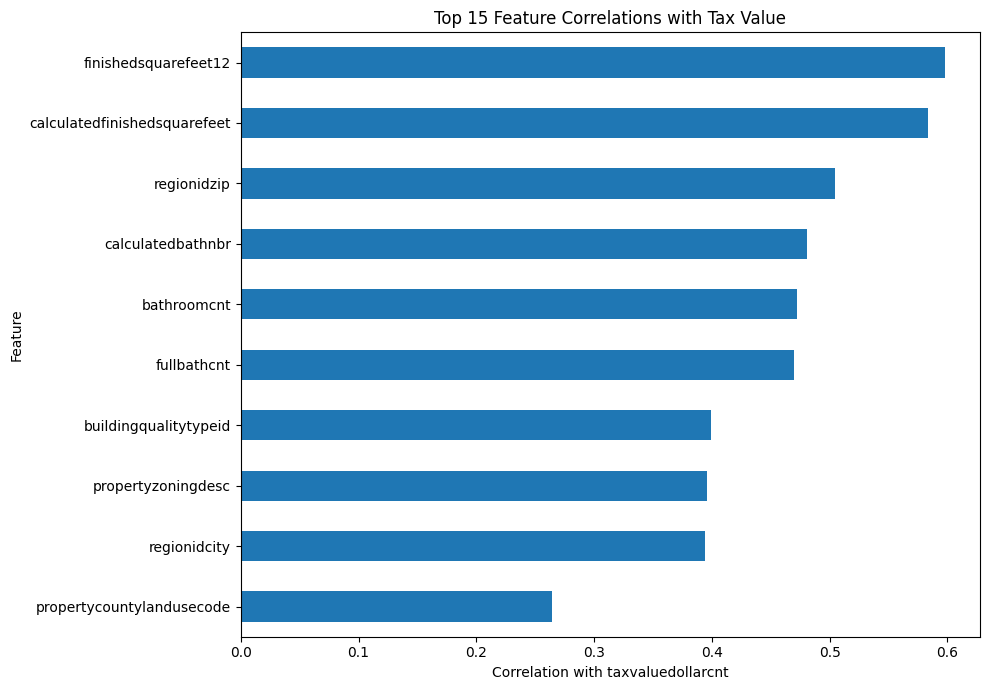

In [172]:
# Visualize the results where appropriate (for example, a heatmap and a bar chart).   --------- using BAR CHART of target correlation

top_target_corr = target_correlations.head(10).sort_values()

plt.figure(figsize=(10, 7))
top_target_corr.plot(kind='barh')
plt.title('Top 15 Feature Correlations with Tax Value')
plt.xlabel('Correlation with taxvaluedollarcnt')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [173]:
#Identify features that appear to have particularly strong or weak relationships with the target.

target_correlations = (
    corr_matrix[target]
    .drop(target)
    .sort_values(key=abs, ascending=False)
)

target_correlations.head(20) #top 10.   #ranking feature by abs based on their correlation to the target 

finishedsquarefeet12            0.597779
calculatedfinishedsquarefeet    0.583320
regionidzip                     0.504676
calculatedbathnbr               0.481140
bathroomcnt                     0.472519
fullbathcnt                     0.469335
buildingqualitytypeid           0.399101
propertyzoningdesc              0.396224
regionidcity                    0.394147
propertycountylandusecode       0.264077
bedroomcnt                      0.248852
heatingorsystemtypeid           0.131849
yearbuilt                       0.119219
propertylandusetypeid           0.100170
latitude                       -0.096899
regionidcounty                  0.043547
fips                            0.043547
longitude                      -0.033738
lotsizesquarefeet              -0.020425
unitcnt                         0.004840
Name: taxvaluedollarcnt, dtype: float64

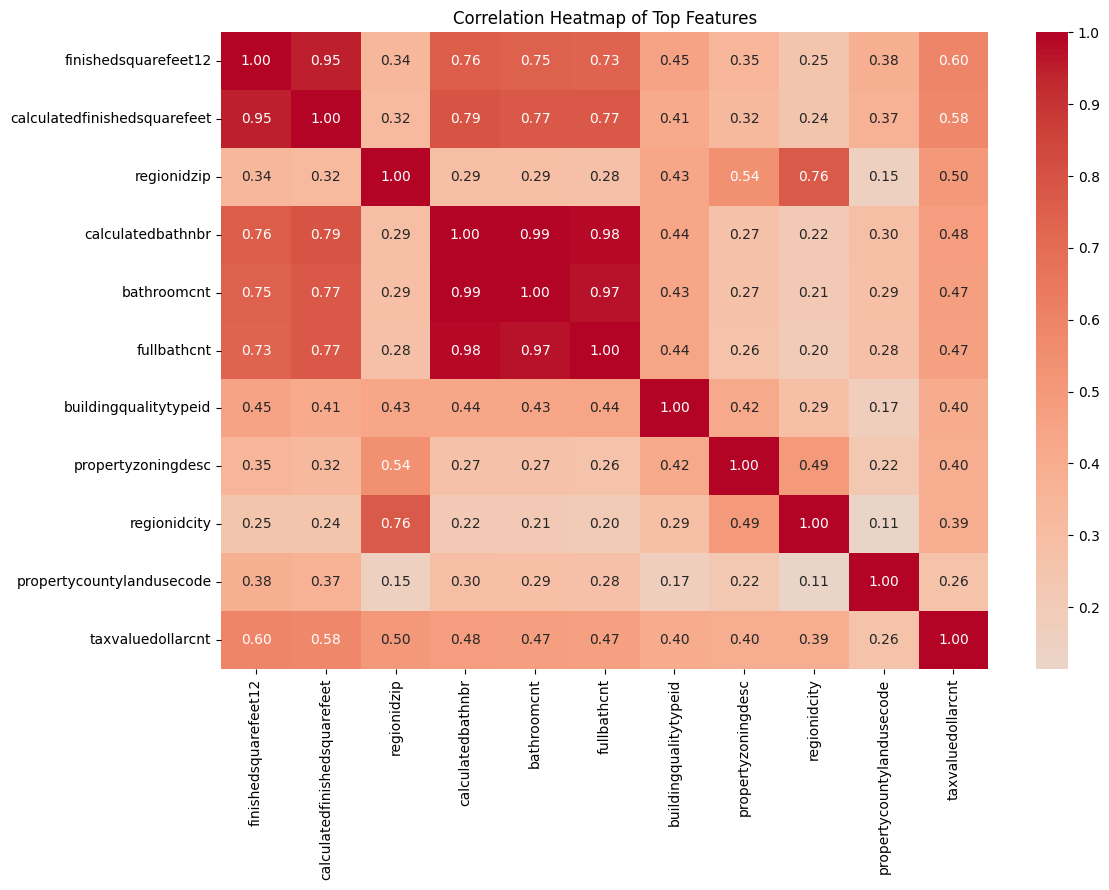

In [174]:
# Visualize the results where appropriate (for example, a heatmap and a bar chart).   --------- using HEAT MAP of target correlation

top_features = target_correlations.head(10).index.tolist()
heatmap_features = top_features + [target]

plt.figure(figsize=(12, 9))
sns.heatmap(
    corr_matrix.loc[heatmap_features, heatmap_features],
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)

plt.title('Correlation Heatmap of Top Features')
plt.tight_layout()
plt.show()

In [ ]:
#Identify pairs of features that appear to be highly correlated.

feature_corr = corr_matrix.drop(index=target, columns=target)

upper_triangle = feature_corr.where(
    np.triu(np.ones(feature_corr.shape), k=1).astype(bool)
)

high_corr_pairs = (
    upper_triangle.stack()
    .reset_index()
)

high_corr_pairs.columns = ['feature_1', 'feature_2', 'correlation']

high_corr_pairs['absolute_correlation'] = (
    high_corr_pairs['correlation'].abs()
)

high_corr_pairs = high_corr_pairs.sort_values(
    'absolute_correlation',
    ascending=False
)

high_corr_pairs.head(10)

,feature_1,feature_2,correlation,absolute_correlation
114,fips,regionidcounty,1.000000,1.000000
2,bathroomcnt,calculatedbathnbr,0.989961,0.989961
60,calculatedbathnbr,fullbathcnt,0.984497,0.984497
6,bathroomcnt,fullbathcnt,0.974027,0.974027
74,calculatedfinishedsquarefeet,finishedsquarefeet12,0.949434,0.949434
57,calculatedbathnbr,calculatedfinishedsquarefeet,0.792748,0.792748
3,bathroomcnt,calculatedfinishedsquarefeet,0.773764,0.773764
76,calculatedfinishedsquarefeet,fullbathcnt,0.773039,0.773039
196,regionidcity,regionidzip,0.764856,0.764856
58,calculatedbathnbr,finishedsquarefeet12,0.758140,0.758140


In [176]:
# compute f stat for feature importance


X = df_model.drop(columns=[target])
y = df_model[target]

X_numeric = X.select_dtypes(include='number')

f_scores, p_values = f_regression(X_numeric, y)

f_results = pd.DataFrame({
    'feature': X_numeric.columns,
    'f_score': f_scores,
    'p_value': p_values
}).sort_values('f_score', ascending=False)

f_results.head(10)

,feature,f_score,p_value
5,finishedsquarefeet12,42998.587215,0.0
4,calculatedfinishedsquarefeet,39883.740404,0.0
17,regionidzip,26426.937621,0.0
3,calculatedbathnbr,23294.319543,0.0
0,bathroomcnt,22229.209378,0.0
7,fullbathcnt,21846.351086,0.0
2,buildingqualitytypeid,14651.038671,0.0
14,propertyzoningdesc,14401.369137,0.0
15,regionidcity,14223.075682,0.0
12,propertycountylandusecode,5797.093206,0.0


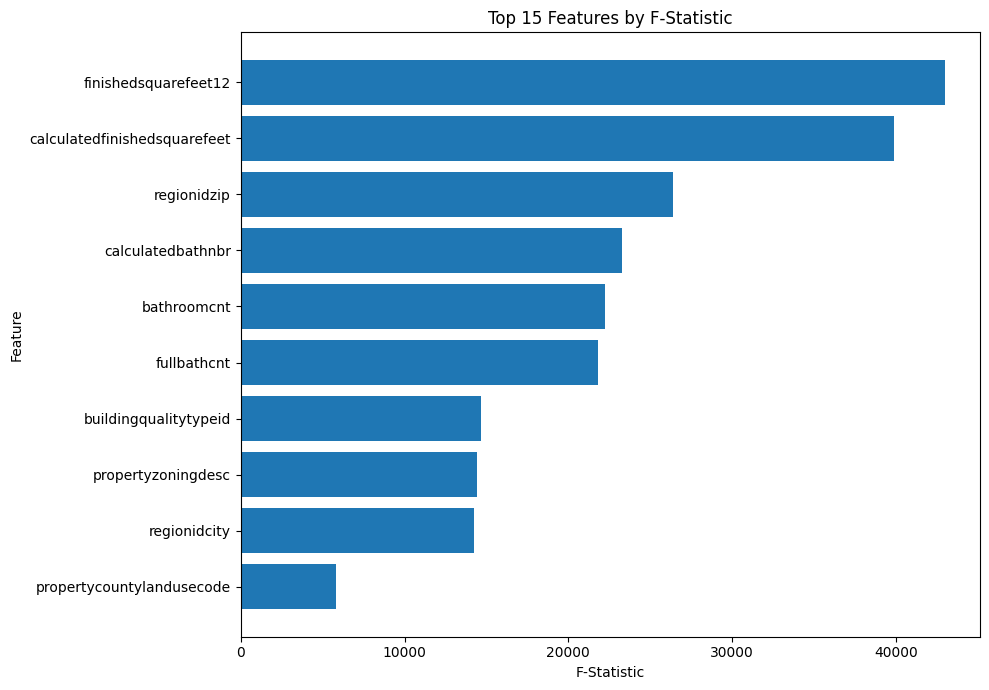

In [ ]:
top_f_results = f_results.head(10).sort_values('f_score')

plt.figure(figsize=(10, 7))
plt.barh(
    top_f_results['feature'],
    top_f_results['f_score']
)

plt.title('Top 10 Features by F-Statistic')
plt.xlabel('F-Statistic')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [178]:
target_correlations.head(10)

finishedsquarefeet12            0.597779
calculatedfinishedsquarefeet    0.583320
regionidzip                     0.504676
calculatedbathnbr               0.481140
bathroomcnt                     0.472519
fullbathcnt                     0.469335
buildingqualitytypeid           0.399101
propertyzoningdesc              0.396224
regionidcity                    0.394147
propertycountylandusecode       0.264077
Name: taxvaluedollarcnt, dtype: float64

In [179]:
high_corr_pairs.head(10)

,feature_1,feature_2,correlation,absolute_correlation
114,fips,regionidcounty,1.000000,1.000000
2,bathroomcnt,calculatedbathnbr,0.989961,0.989961
60,calculatedbathnbr,fullbathcnt,0.984497,0.984497
6,bathroomcnt,fullbathcnt,0.974027,0.974027
74,calculatedfinishedsquarefeet,finishedsquarefeet12,0.949434,0.949434
57,calculatedbathnbr,calculatedfinishedsquarefeet,0.792748,0.792748
3,bathroomcnt,calculatedfinishedsquarefeet,0.773764,0.773764
76,calculatedfinishedsquarefeet,fullbathcnt,0.773039,0.773039
196,regionidcity,regionidzip,0.764856,0.764856
58,calculatedbathnbr,finishedsquarefeet12,0.758140,0.758140


In [180]:
f_results.head(10)

,feature,f_score,p_value
5,finishedsquarefeet12,42998.587215,0.0
4,calculatedfinishedsquarefeet,39883.740404,0.0
17,regionidzip,26426.937621,0.0
3,calculatedbathnbr,23294.319543,0.0
0,bathroomcnt,22229.209378,0.0
7,fullbathcnt,21846.351086,0.0
2,buildingqualitytypeid,14651.038671,0.0
14,propertyzoningdesc,14401.369137,0.0
15,regionidcity,14223.075682,0.0
12,propertycountylandusecode,5797.093206,0.0


#### **4.A Discussion:**

Describe the strongest relationships you observed among the features and between the features and the target.

In particular, discuss:

- Which features appeared to be the strongest predictors of the target.
- Which pairs of features appeared to be highly correlated.
- Whether the correlation matrix and the F-statistics led you to similar conclusions about the most important features. Explain your reasoning.

>The strongest predictors of taxvaluedollarcnt were mostly features related to home size and bathrooms. The highest correlations were finishedsquarefeet12 (0.598), calculatedfinishedsquarefeet (0.583), regionidzip (0.505), calculatedbathnbr (0.481), and bathroomcnt (0.473). This suggests that larger homes, homes with more bathrooms, and property location all play an important role in predicting property value.

>We also found several feature pairs with very high correlations. For example, fips and regionidcounty had a perfect correlation (1.00), while bathroomcnt and calculatedbathnbr, calculatedbathnbr and fullbathcnt, and calculatedfinishedsquarefeet and finishedsquarefeet12 were all highly correlated. This suggests that some of these features are measuring very similar information and may be somewhat redundant.

>The correlation analysis and F-statistics pointed to many of the same features. Both ranked finishedsquarefeet12, calculatedfinishedsquarefeet, regionidzip, calculatedbathnbr, bathroomcnt, and fullbathcnt among the most important predictors, giving us more confidence that these features will be useful when building the model.

### Part 4.B: Investigate Feature Relationships

In this part, you will explore relationships between pairs of features to better understand the structure of the dataset and identify opportunities for future feature engineering.

In the next cell(s):

- Select three interesting pairs of features to investigate. Choose pairs that you think may have meaningful relationships based on your earlier exploratory analysis.
- Visualize each pair using an appropriate plot, such as a scatter plot, pairplot, box plot, or another suitable visualization.
- Describe the relationship you observe. Consider whether it appears to be linear, nonlinear, weak, strong, or whether little relationship is evident.
- Do not modify the dataset based on these analyses. Any feature engineering or preprocessing decisions will be evaluated experimentally in Milestone 2.

We decided to chose the following predictors
- calculatedfinishedsquarefeet x finishedsquarefeet12
- bathroomcnt x calculatedbathnbr
- regionidzip x taxvaluedollarcnt

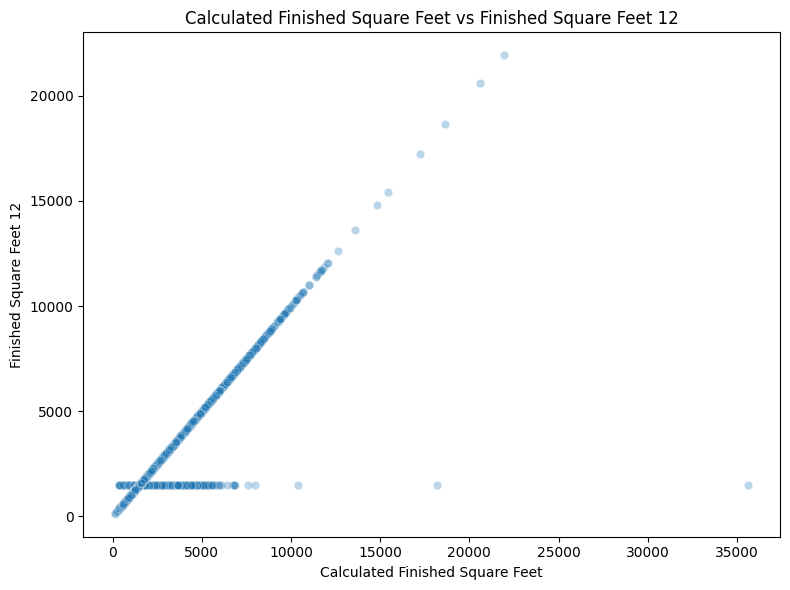

In [181]:


# Pair 1: Two measures of finished square footage
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_model,
    x='calculatedfinishedsquarefeet',
    y='finishedsquarefeet12',
    alpha=0.3
)
plt.title('Calculated Finished Square Feet vs Finished Square Feet 12')
plt.xlabel('Calculated Finished Square Feet')
plt.ylabel('Finished Square Feet 12')
plt.tight_layout()
plt.show()

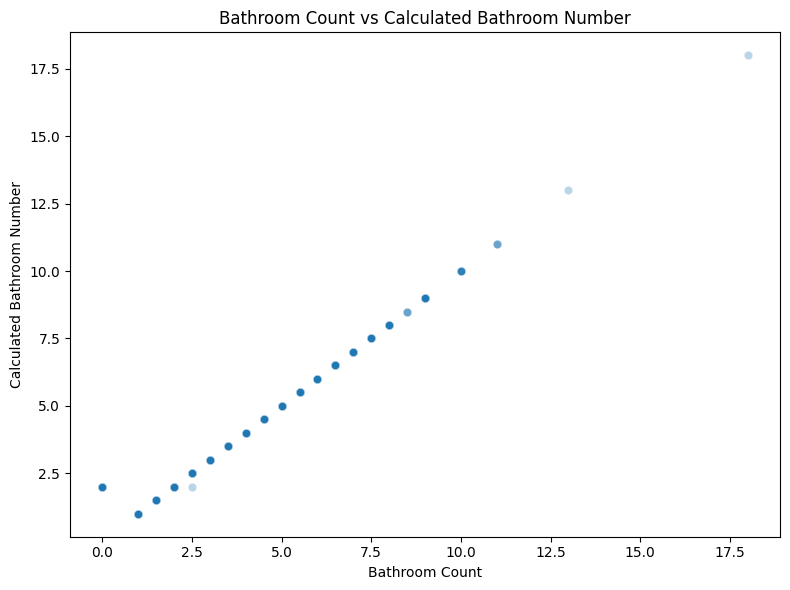

In [182]:
# Pair 2: Two measures of bathroom count
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_model,
    x='bathroomcnt',
    y='calculatedbathnbr',
    alpha=0.3
)
plt.title('Bathroom Count vs Calculated Bathroom Number')
plt.xlabel('Bathroom Count')
plt.ylabel('Calculated Bathroom Number')
plt.tight_layout()
plt.show()

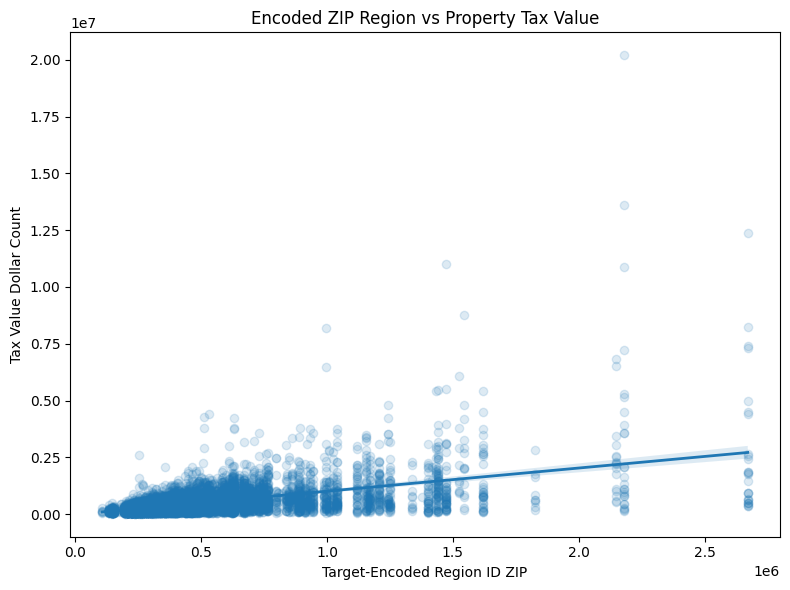

In [185]:
# # Pair 3: Encoded ZIP-region feature vs target
plt.figure(figsize=(8, 6))
sns.regplot(
    data=plot_sample,
    x='regionidzip',
    y='taxvaluedollarcnt',
    scatter_kws={'alpha': 0.15},
    line_kws={'linewidth': 2}
)
plt.title('Encoded ZIP Region vs Property Tax Value')
plt.xlabel('Target-Encoded Region ID ZIP')
plt.ylabel('Tax Value Dollar Count')
plt.tight_layout()
plt.show()

#### **4.B Discussion:**

Describe what you learned from the three feature relationships you investigated.

For each pair, discuss:

- The overall pattern you observed (for example, linear, nonlinear, weak, or strong).
- What the relationship suggests about the features and their potential usefulness for predicting the target.
- Whether your observations suggest possible feature engineering or preprocessing ideas that could be investigated in **Milestone 2**.

> calculatedfinishedsquarefeet and finishedsquarefeet12 had a very strong linear relationship, which makes sense since both measure the size of the home. bathroomcnt and calculatedbathnbr also had an almost perfect relationship, suggesting they provide very similar information. The relationship between target-encoded regionidzip and taxvaluedollarcnt was moderately positive, showing that location also plays a role in property value. Overall, home size, bathrooms, and location appear to be the most important predictors. In Milestone 2, we can test whether combining or removing highly correlated features and creating new features improves model performance.


## Part 5: Investigate Potential Feature Engineering [6 pts]

In this part, you will identify potential feature engineering and preprocessing techniques that **may** improve model performance.

The goal is to develop hypotheses based on your exploratory data analysis—not to permanently modify the dataset. In **Milestone 2**, you will evaluate these ideas experimentally and determine whether they actually improve the model.

**Important:** Do **not** permanently transform, remove, or add features in this milestone.

## Part 5.A: Identify Potential Feature Engineering Opportunities

Based on your exploratory analysis, identify **at least three (3)** feature engineering or preprocessing techniques that you believe may improve model performance.

Possible ideas include (but are not limited to):

- Log transformations
- Scaling or normalization
- Removing highly correlated features
- Polynomial features
- Interaction features
- Binning continuous variables
- Outlier removal
- Combining or aggregating existing features

You may investigate these ideas by creating visualizations or performing exploratory analyses, but **do not permanently modify the dataset**.

#### **5.A Discussion:**

Describe the three feature engineering or preprocessing ideas you identified.

For each one, explain:

- Which feature(s) it would affect.
- Why you believe it may improve model performance.
- How you would determine in **Milestone 2** whether it actually improves the model (for example, by comparing appropriate evaluation metrics on a validation or test set).

> Replace this text with your answer.

>Remove or combine highly correlated features, such as bathroomcnt and calculatedbathnbr or calculatedfinishedsquarefeet and finishedsquarefeet12. Since these features are measuring very similar things, reducing the redundancy may help simplify the model. In Milestone 2, we can compare model performance before and after making these changes.

>Apply a log transformation to taxvaluedollarcnt since the data contains some very expensive properties that create outliers. This could reduce the effect of those extreme values and improve model performance. In Milestone 2, we can compare the results before and after applying the transformation.

>Create interaction features using important predictors, such as home size and bathroom count. These combined features may capture relationships that individual features miss. In Milestone 2, we can compare model performance with and without these interaction features.

## Part 5.B: Prioritize Your Ideas

Not all feature engineering ideas are equally promising.

Based on your investigation, select the **two** ideas you believe are most likely to improve model performance.

Briefly explain why you selected these ideas over the others.

No code is required for this section.

#### **5.B Discussion:**

Suppose you had time to evaluate only **two** feature engineering or preprocessing ideas in **Milestone 2**.

For each one, explain:

- Which idea you would prioritize.
- Why you believe it is the most promising.
- What evidence from your exploratory analysis (such as feature distributions, missing values, feature relationships, or other observations) led you to this conclusion.

> Replace this text with your answer.

>If I could only test two ideas, I would focus on applying a log transformation to the target and removing or combining highly correlated features. The data contains some high-value outliers, so a log transformation could help improve the model. We also found feature pairs like bathroomcnt and calculatedbathnbr that are almost identical, so reducing that redundancy may improve performance. In Milestone 2, we can test both ideas by comparing the model's performance before and after making these changes.

## **Appendix 1: Features of the Zillow Dataset**  

0. **parcelid**: Unique identifier for the property parcel.  
1. **airconditioningtypeid**: Identifier for the type of air conditioning installed.  
2. **architecturalstyletypeid**: Identifier for the architectural style of the property.  
3. **basementsqft**: Square footage of the basement.  
4. **bathroomcnt**: Number of bathrooms.  
5. **bedroomcnt**: Number of bedrooms.  
6. **buildingclasstypeid**: Identifier for the building framing type (e.g., wood frame, steel frame).  
7. **buildingqualitytypeid**: Numeric value indicating the quality of the building (higher values often indicate better quality).  
8. **calculatedbathnbr**: Calculated number of bathrooms, including fractional bathrooms.  
9. **decktypeid**: Identifier for the type of deck.  
10. **finishedfloor1squarefeet**: Square footage of the finished area on the first floor.  
11. **calculatedfinishedsquarefeet**: Total finished living area square footage.  
12. **finishedsquarefeet12**: Finished living area square footage.  
13. **finishedsquarefeet13**: Perimeter living area square footage.  
14. **finishedsquarefeet15**: Total area.  
15. **finishedsquarefeet50**: Square footage of the finished area on the upper floors.  
16. **finishedsquarefeet6**: Base unfinished and finished area square footage.  
17. **fips**: Federal Information Processing Standards code, uniquely identifying counties and county equivalents.  
18. **fireplacecnt**: Number of fireplaces.  
19. **fullbathcnt**: Number of full bathrooms.  
20. **garagecarcnt**: Number of cars that can fit in the garage.  
21. **garagetotalsqft**: Total square footage of the garage.  
22. **hashottuborspa**: Indicates if the property has a hot tub or spa.  
23. **heatingorsystemtypeid**: Identifier for the type of heating system.  
24. **latitude**: Latitude coordinate of the property.  
25. **longitude**: Longitude coordinate of the property.  
26. **lotsizesquarefeet**: Lot size in square feet.  
27. **poolcnt**: Number of pools on the property.  
28. **poolsizesum**: Total square footage of all pools.  
29. **pooltypeid10**: Identifier for spa or hot tub.  
30. **pooltypeid2**: Identifier for pool with spa or hot tub.  
31. **pooltypeid7**: Identifier for pool without hot tub or spa.  
32. **propertycountylandusecode**: County land use code for the property.  
33. **propertylandusetypeid**: Identifier for the property land use type.  
34. **propertyzoningdesc**: Description of the property's zoning.  
35. **rawcensustractandblock**: Unprocessed census tract and block identifier.  
36. **regionidcity**: Identifier for the city.  
37. **regionidcounty**: Identifier for the county.  
38. **regionidneighborhood**: Identifier for the neighborhood.  
39. **regionidzip**: Identifier for the ZIP code.  
40. **roomcnt**: Total number of rooms.  
41. **storytypeid**: Identifier for the type of stories in the building (e.g., basement, attic).  
42. **threequarterbathnbr**: Number of 3/4 bathrooms (typically includes a shower but no tub).  
43. **typeconstructiontypeid**: Identifier for the type of construction (e.g., frame, masonry).  
44. **unitcnt**: Number of units in the building (e.g., for multi-family properties).  
45. **yardbuildingsqft17**: Square footage of the 17th yard building (e.g., shed).  
46. **yardbuildingsqft26**: Square footage of the 26th yard building.  
47. **yearbuilt**: Year the property was built.  
48. **numberofstories**: Number of stories in the building.  
49. **fireplaceflag**: Indicates if the property has a fireplace.  
50. **assessmentyear**: Year the property was assessed.  
51. **taxdelinquencyflag**: Indicates whether the property’s taxes are delinquent. Often “Y” if taxes are past due; otherwise null/empty.  
52. **taxdelinquencyyear**: The year in which the property’s taxes became delinquent.  
53. **censustractandblock**: A combined identifier for the property’s census tract and block group (part of the U.S. Census geographic hierarchy).  
54. **taxvaluedollarcnt**: Total assessed value of the property (land plus structure) in dollars.  


## Appendix 2: Summary of Basic Imputation Methods
Imputation depends on the data type and context. Below are common techniques for handling missing values.

---

### **1. Simple Imputation (Basic Methods)**
| Method | Best For | Code Example | Pros | Cons |
|--------|---------|--------------|------|------|
| **Drop Missing Values** | Few missing values (<5% of data) | `df.dropna()` | Quick and easy | Can remove valuable data |
| **Mean Imputation** | Normally distributed numerical data | `df.fillna(df.mean())` | Preserves mean; simple | Distorts variance, weak for skewed data |
| **Median Imputation** | Skewed numerical data | `df.fillna(df.median())` | Robust to outliers | May not capture patterns |
| **Mode Imputation** | Categorical features | `df.fillna(df.mode().iloc[0])` | Keeps most common category | Can introduce bias |
| **Constant Value (e.g., 0)** | Special cases (e.g., unknown numerical data) | `df.fillna(0)` | Simple and interpretable | Can mislead model |
| **"Unknown" Category Imputation** (**New Addition**) | Categorical features with missing values | `df.fillna('Unknown')` | Keeps all rows, prevents data loss | May introduce artificial category |

---

### **2. Statistical & Advanced Imputation**
| Method | Best For | Code Example | Pros | Cons |
|--------|---------|--------------|------|------|
| **Interpolation** | Time series, ordered data | `df.interpolate(method='linear')` | Preserves trends | May not work for non-continuous data |
| **K-Nearest Neighbors (KNN)** | Small datasets, patterns in features | `KNNImputer(n_neighbors=5).fit_transform(df)` | Uses similar observations | Computationally expensive |
| **Multivariate Imputation (MICE)** | Complex relationships between variables | `IterativeImputer().fit_transform(df)` | Captures relationships | Slower than mean/median |
| **Regression Imputation** | When missing values depend on other variables | Train regression model to predict missing values | More accurate than mean/median | Risk of overfitting |

---

### **When to Use "Unknown" Category for Categorical Imputation**
✅ **Good for:**
- Categorical features where missing values may indicate meaningful differences.  
- Customer data (e.g., missing survey responses → "No Response").  
- Product categories where missing could be a separate group.  

❌ **Avoid if:**
- The missing category does **not** have a meaningful interpretation.
- The model might learn spurious patterns from an artificial category.

---

### **Which Method to Choose?**
| Scenario | Best Method |
|----------|------------|
| **Few missing values (<5%)** | Drop NaNs (`df.dropna()`) |
| **Numerical & normal distribution** | Mean (`df.fillna(df.mean())`) |
| **Numerical & skewed distribution** | Median (`df.fillna(df.median())`) |
| **Categorical features** | Mode (`df.fillna(df.mode().iloc[0])`) |
| **Categorical with possible meaning in missingness** | "Unknown" Category (`df.fillna('Unknown')`) |
| **Small dataset with patterns** | KNN Imputer (`KNNImputer()`) |
| **Complex relationships between features** | MICE / Iterative Imputer |



## Appendix 3: Flowchart for Identifying Feature Types

The following flowchart can help you identify the statistical type of each feature and determine an appropriate encoding strategy for categorical variables.

